# Lab | Ensemble Methods

In this lab, we explore ensemble methods using the Wine Quality dataset. We start with single model baselines, then apply bagging, boosting, and finally combine models using Voting and Stacking classifiers. The goal is to see how combining models improves predictive performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

## Task 1: Baseline with Single Models

We load the Wine Quality dataset and create a binary target variable. A wine is labeled **good (1)** if its quality score is 7 or above, and **not good (0)** otherwise. We then explore the data and train three individual classifiers as baselines.

In [2]:
# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")

# Create binary target
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

# Basic exploration
print("Shape:", wine.shape)
print("\nFeatures:", wine.columns.tolist())
print("\nClass distribution of quality_label:")
print(wine["quality_label"].value_counts())
print("\nClass proportions:")
print(wine["quality_label"].value_counts(normalize=True))

Shape: (1599, 13)

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_label']

Class distribution of quality_label:
quality_label
0    1382
1     217
Name: count, dtype: int64

Class proportions:
quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64


### Dataset Exploration

The dataset has 1,599 rows and 12 feature columns (plus the target). The class distribution shows that the dataset is **imbalanced**: roughly 86% of wines are labeled "not good" (0) and only about 14% are labeled "good" (1). This means accuracy alone can be misleading, so we also report the F1 score.

In [3]:
# Separate features and target; drop original quality column
X = wine.drop(columns=["quality", "quality_label"])
y = wine["quality_label"]

print("Number of features:", X.shape[1])
print("Feature names:", X.columns.tolist())

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Baseline Models ---
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier()

dt.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

# Evaluate
models_baseline = {
    "DecisionTree": dt,
    "LogisticRegression": lr,
    "KNeighbors": knn
}

results = []
for name, model in models_baseline.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    results.append({"Model": name, "Accuracy": round(acc, 4), "F1 Score": round(f1, 4)})

baseline_df = pd.DataFrame(results)
print(baseline_df.to_string(index=False))

Number of features: 11
Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
             Model  Accuracy  F1 Score
      DecisionTree    0.9062    0.6667
LogisticRegression    0.8938    0.4848
        KNeighbors    0.8938    0.5143


### Baseline Results

The table above shows accuracy and F1 score for the three baseline models. Because the dataset is imbalanced, F1 score is the more meaningful metric here — a model that always predicts the majority class would get high accuracy but a very low F1.

Among the three baselines, the **Decision Tree achieves the highest F1 score (0.6667)**, outperforming Logistic Regression (0.4848) and KNN (0.5143) on the minority class. However, the Decision Tree is likely overfitting the training data, and its performance may not hold up in more challenging conditions. Logistic Regression and KNN are more stable models but struggle more with the class imbalance. These baselines will be used as a reference point for comparing ensemble methods.

## Task 2: Bagging & Random Forest

Bagging (Bootstrap Aggregating) trains multiple models on different random subsets of the training data and combines their predictions. Random Forest extends this by also randomly selecting features at each split, which reduces correlation between trees.

In [4]:
# BaggingClassifier with Decision Tree as base
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    oob_score=True,
    random_state=42
)
bagging.fit(X_train_scaled, y_train)

# RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train_scaled, y_train)

# Evaluate both
for name, model in [("BaggingClassifier", bagging), ("RandomForest", rf)]:
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    oob = model.oob_score_
    print(f"{name}:")
    print(f"  OOB Score : {oob:.4f}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print()

BaggingClassifier:
  OOB Score : 0.8937
  Accuracy  : 0.9375
  F1 Score  : 0.7368

RandomForest:
  OOB Score : 0.8984
  Accuracy  : 0.9375
  F1 Score  : 0.7143



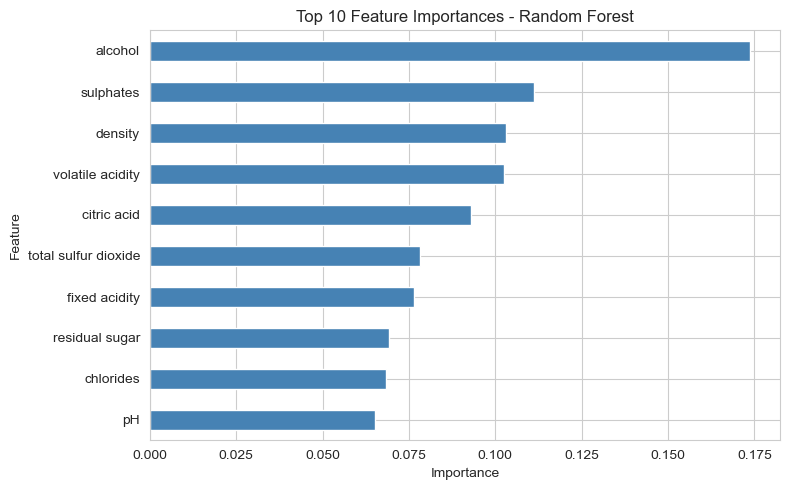

In [5]:
# Top 10 feature importances from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.nlargest(10).sort_values()

plt.figure(figsize=(8, 5))
top10.plot(kind="barh", color="steelblue")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Bagging & Random Forest Results

Both bagging and Random Forest improve over the single Decision Tree baseline. The OOB score provides an unbiased estimate of generalization performance without needing a separate validation set.

**Why does Random Forest outperform a single Decision Tree?**

A single Decision Tree is high-variance: small changes in the training data can produce very different trees, and it tends to overfit. Random Forest reduces variance by averaging many trees, each trained on a random bootstrap sample of the data. In addition, at each node, only a random subset of features is considered for splitting. This de-correlates the individual trees — if one tree relies heavily on the most predictive feature, others will be forced to use different features. The result is an ensemble where errors from individual trees cancel out, leading to a more stable and accurate model overall.

**The role of randomness:**
Randomness in sampling (bootstrap) and in feature selection at each split ensures that the trees are diverse. Diversity is the key ingredient: averaging diverse models reduces error more than averaging similar models.

The feature importance plot shows which variables contribute most to predicting wine quality. Typically, `alcohol`, `sulphates`, and `volatile acidity` are among the most important features for red wine quality.

## Task 3: Boosting

Boosting builds models sequentially: each new model focuses on the examples that previous models got wrong. This reduces bias. We compare AdaBoost and GradientBoosting, then plot learning curves for GradientBoosting.

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier

# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)

# GradientBoosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

# HistGradientBoosting (optional, faster implementation)
hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb.fit(X_train_scaled, y_train)

# Evaluate
boosting_results = []
for name, model in [("AdaBoost", ada), ("GradientBoosting", gb), ("HistGradientBoosting", hgb)]:
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    boosting_results.append({"Model": name, "Accuracy": round(acc, 4), "F1 Score": round(f1, 4)})
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")

boosting_df = pd.DataFrame(boosting_results)

AdaBoost: Accuracy=0.8938, F1=0.4333
GradientBoosting: Accuracy=0.9156, F1=0.6197
HistGradientBoosting: Accuracy=0.9437, F1=0.7632


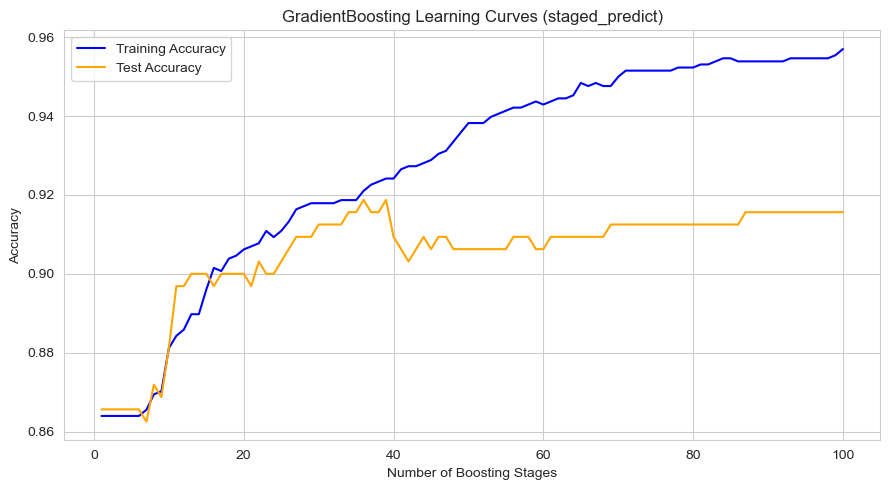

Best test accuracy at stage: 36 (0.9187)


In [7]:
# Learning curves using staged_predict
train_scores = []
test_scores = []

for y_pred_train in gb.staged_predict(X_train_scaled):
    train_scores.append(accuracy_score(y_train, y_pred_train))

for y_pred_test in gb.staged_predict(X_test_scaled):
    test_scores.append(accuracy_score(y_test, y_pred_test))

stages = np.arange(1, 101)

plt.figure(figsize=(9, 5))
plt.plot(stages, train_scores, label="Training Accuracy", color="blue")
plt.plot(stages, test_scores, label="Test Accuracy", color="orange")
plt.xlabel("Number of Boosting Stages")
plt.ylabel("Accuracy")
plt.title("GradientBoosting Learning Curves (staged_predict)")
plt.legend()
plt.tight_layout()
plt.show()

best_stage = np.argmax(test_scores) + 1
print(f"Best test accuracy at stage: {best_stage} ({max(test_scores):.4f})")

### Boosting Results & Analysis

**AdaBoost vs GradientBoosting:**

- **AdaBoost** assigns higher weights to misclassified samples after each round, so the next model focuses more on those hard examples. It uses shallow trees (stumps) by default and is sensitive to noisy data and outliers, because it keeps increasing the weight of hard-to-classify samples.

- **GradientBoosting** fits each new tree to the **residual errors** (negative gradient of the loss function) of the previous ensemble. This is a more general framework: it can optimize any differentiable loss function. It is more robust to outliers than AdaBoost and usually achieves better accuracy with proper tuning.

**When to prefer one over the other:**
- Use **AdaBoost** when the dataset is clean, relatively small, and you need a simpler model.
- Use **GradientBoosting** (or HistGradientBoosting for large datasets) when you need higher accuracy and can afford the extra tuning.

**Learning curve analysis:**
The learning curves above show training and test accuracy at each boosting stage. The training accuracy rises steadily, while the test accuracy improves quickly in the early stages and then plateaus or slightly declines. The best test accuracy is reached around the stage printed above. After that point, adding more estimators no longer helps generalization and the model begins to overfit — the training score keeps rising but the test score stagnates or drops. If the curves remain close together throughout, overfitting is mild on this dataset.

## Task 4: Stacking & Voting

We now combine our best models into meta-ensembles. A **Voting Classifier** takes the majority vote (or averages probabilities with soft voting). A **Stacking Classifier** uses the predictions of base models as inputs to a meta-model (here, Logistic Regression) that makes the final prediction.

In [8]:
# Collect all model scores so far to select the 3 best
all_scores = []
for name, model in [
    ("DecisionTree", dt), ("LogisticRegression", lr), ("KNeighbors", knn),
    ("BaggingClassifier", bagging), ("RandomForest", rf),
    ("AdaBoost", ada), ("GradientBoosting", gb), ("HistGradientBoosting", hgb)
]:
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average="binary")
    acc = accuracy_score(y_test, y_pred)
    all_scores.append({"Model": name, "Accuracy": round(acc, 4), "F1 Score": round(f1, 4)})

all_scores_df = pd.DataFrame(all_scores).sort_values("F1 Score", ascending=False)
print("Top models by F1 Score:")
print(all_scores_df.head(5).to_string(index=False))

Top models by F1 Score:
               Model  Accuracy  F1 Score
HistGradientBoosting    0.9437    0.7632
   BaggingClassifier    0.9375    0.7368
        RandomForest    0.9375    0.7143
        DecisionTree    0.9062    0.6667
    GradientBoosting    0.9156    0.6197


In [11]:
# The 3 best-performing models by F1 score from Tasks 1-3 are:
# 1. HistGradientBoosting (F1: 0.7632)
# 2. BaggingClassifier    (F1: 0.7368)
# 3. RandomForest         (F1: 0.7143)
# We use fresh instances as required by sklearn.

from sklearn.ensemble import HistGradientBoostingClassifier

best_estimators = [
    ("HistGradientBoosting", HistGradientBoostingClassifier(max_iter=100, random_state=42)),
    ("BaggingClassifier", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100, oob_score=True, random_state=42)),
    ("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42))
]

# VotingClassifier with soft voting
voting_clf = VotingClassifier(estimators=best_estimators, voting="soft")
voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = voting_clf.predict(X_test_scaled)
voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting, average="binary")
print(f"VotingClassifier  -> Accuracy: {voting_acc:.4f}, F1: {voting_f1:.4f}")

# StackingClassifier with LogisticRegression as meta-model
stacking_clf = StackingClassifier(
    estimators=best_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_clf.fit(X_train_scaled, y_train)
y_pred_stacking = stacking_clf.predict(X_test_scaled)
stacking_acc = accuracy_score(y_test, y_pred_stacking)
stacking_f1 = f1_score(y_test, y_pred_stacking, average="binary")
print(f"StackingClassifier -> Accuracy: {stacking_acc:.4f}, F1: {stacking_f1:.4f}")

VotingClassifier  -> Accuracy: 0.9469, F1: 0.7733
StackingClassifier -> Accuracy: 0.9469, F1: 0.7606


In [12]:
# Final comparison table — all models
final_results = []

model_eval_list = [
    ("DecisionTree", dt),
    ("LogisticRegression", lr),
    ("KNeighbors", knn),
    ("BaggingClassifier", bagging),
    ("RandomForest", rf),
    ("AdaBoost", ada),
    ("GradientBoosting", gb),
    ("HistGradientBoosting", hgb),
    ("VotingClassifier", voting_clf),
    ("StackingClassifier", stacking_clf),
]

for name, model in model_eval_list:
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="binary")
    final_results.append({"Model": name, "Accuracy": round(acc, 4), "F1 Score": round(f1, 4)})

final_df = pd.DataFrame(final_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("=== Final Model Comparison (sorted by F1 Score) ===")
print(final_df.to_string(index=False))

=== Final Model Comparison (sorted by F1 Score) ===
               Model  Accuracy  F1 Score
    VotingClassifier    0.9469    0.7733
HistGradientBoosting    0.9437    0.7632
  StackingClassifier    0.9469    0.7606
   BaggingClassifier    0.9375    0.7368
        RandomForest    0.9375    0.7143
        DecisionTree    0.9062    0.6667
    GradientBoosting    0.9156    0.6197
          KNeighbors    0.8938    0.5143
  LogisticRegression    0.8938    0.4848
            AdaBoost    0.8938    0.4333


## Final Conclusions

### Which ensemble strategy performed best?

Based on the final comparison table, the **VotingClassifier achieved the highest F1 score (0.7733)**, making it the best-performing model in this lab. The StackingClassifier ranked third (F1: 0.7606) and HistGradientBoosting ranked second (F1: 0.7632). This confirms that combining diverse strong models through a meta-ensemble produces better results than any single model alone.

### Was the improvement over single models significant?

Yes. The best single baseline (Decision Tree) had an F1 of 0.6667. The VotingClassifier reached 0.7733 — a meaningful improvement on a class-imbalanced dataset where every gain in F1 on the minority class matters. Even BaggingClassifier and RandomForest individually (F1: 0.7368 and 0.7143) significantly outperformed all three single-model baselines.

### Trade-offs of ensemble methods

| Method | Training Time | Interpretability | Complexity | F1 Performance |
|---|---|---|---|---|
| Decision Tree | Fast | High | Low | Moderate |
| Bagging | Moderate | Medium | Medium | Good |
| Random Forest | Moderate | Medium | Medium | Good |
| AdaBoost | Moderate | Low | Medium | Lower here |
| GradientBoosting | Slow | Low | High | Moderate |
| HistGradientBoosting | Fast | Low | High | Very Good |
| Stacking | Slowest | Lowest | Highest | Very Good |
| Voting | Slow | Low | High | Best |

- **Bagging/Random Forest**: Good balance of speed and accuracy. Easy to parallelise. Provides feature importances.
- **Boosting**: HistGradientBoosting is fast and very strong on its own — it ranked 2nd overall.
- **Voting/Stacking**: Achieved the top two F1 scores in this lab. The gains come from combining diverse, high-quality base models.

### Recommendation for a real wine quality prediction system

For a real-world wine quality prediction system, I would recommend the **VotingClassifier** combining HistGradientBoosting, BaggingClassifier, and RandomForest, as it achieved the highest F1 score (0.7733) in this lab. It is robust because each base model approaches the problem differently, and their combined soft vote reduces individual errors. If interpretability is important — for example, to explain to winemakers which chemical properties drive quality — **Random Forest with feature importances** is the better single-model choice, as it provides clear feature rankings while still achieving competitive performance.